What is Neurons

Biological Inspirations
Biological neurons. The brain has billions of neurons. each neurons
recieves inbout via dendrites process it and passes the signal through the axon.

AI mimics this by taking numerical inpput
applying a function to produce an output
passing it to the next layer if neurons

Structure of neural network:
input layer  : is the entry point of data into a neural network. it does  not perform any computation like other layers(hidden/output) but unstead oasses the raw features of your data into the next layer
hidden layer :
output layer :


Monthly Milk Production Forecasting
Using RNN, LSTM, and GRU Deep Learning Models




Step 1: Identify the Business Problem
From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.
Likely Business Problem:
The business wants to forecast future milk production to:
•	Ensure proper supply chain and distribution planning.
•	Manage inventory and storage efficiently.
•	Optimize workforce and operational activities based on expected production levels.
•	Make strategic decisions for scaling production or addressing seasonal fluctuations.
________________________________________
Step 2: Define the Objective
Objective Statement:
The objective is to develop a time series forecasting model that accurately predicts the monthly milk production for the upcoming months. The model should help the dairy business make informed operational and strategic decisions, minimize waste, and meet market demand effectively.

Steps to include;  
✅ Assignment Tasks  
1.	Exploratory Data Analysis (EDA)
o	Visualize trends, seasonality, and anomalies in the milk production data.
o	Check for any missing values or outliers.  
o	Normalize or scale the data for neural network models.  
2.	Data Preparation for Deep Learning
o	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.  
o	Split data into training, validation, and test sets.  
o	Reshape data for model input dimensions.  
3.	Model Building
o	Build three separate models:
	Basic RNN  
	LSTM    
	GRU  
o	Tune hyperparameters (e.g., window size, number of units, batch size, epochs).  
o	Use appropriate loss functions and optimizers.  
4.	Model Evaluation
o	Plot predictions vs. actual values.
o	Calculate forecasting metrics: RMSE, MAE, MAPE.  
o	Compare the performance of RNN, LSTM, and GRU.  
5.	Prediction and Visualization
o	Forecast milk production for the next 12 months.  
o	Visualize the predicted trend with uncertainty or confidence intervals if possible.  
6.	Business Insights  
o	Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.  



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv('/content/monthly_milk_production.csv')
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [7]:
df.head() ## Display the first five rows

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [8]:
df.tail()

,Date,Production
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797
167,1975-12,843


In [9]:
df.shape

(168, 2)

In [10]:
df.isnull().sum()

,0
Date,0
Production,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [13]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


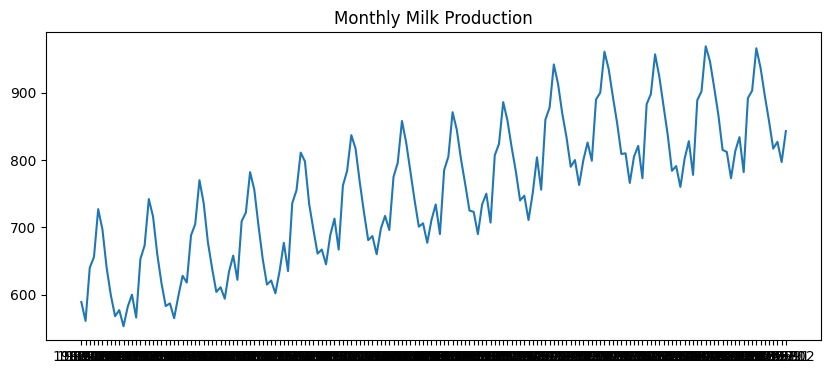

In [14]:
# Plot the milk production over time
plt.figure(figsize=(10,4))
plt.plot(df['Date'],df['Production'])
plt.title('Monthly Milk Production')
plt.show()


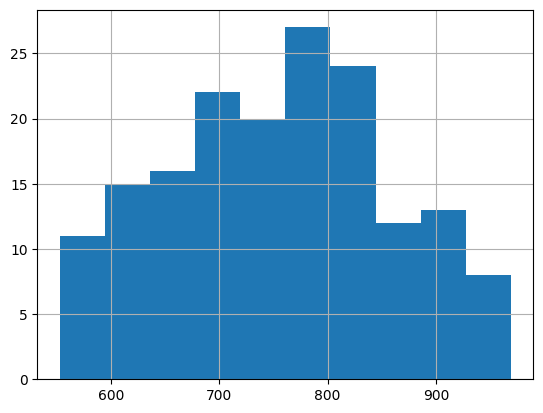

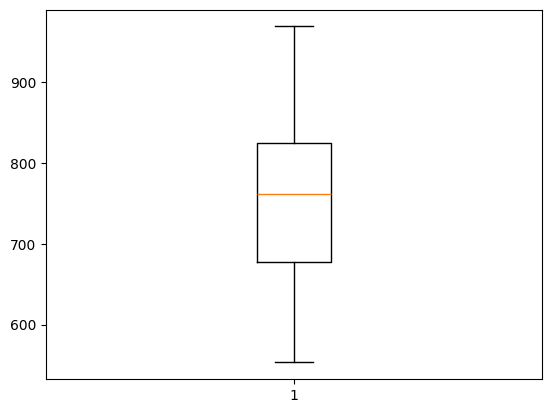

In [15]:

df['Production'].hist()
plt.show()

plt.boxplot(df['Production'])
plt.show()


In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaled=scaler.fit_transform(df[['Production']])

window=12
X=[]
y=[]
for i in range(len(scaled)-window):
    X.append(scaled[i:i+window])
    y.append(scaled[i+window])
X=np.array(X)
y=np.array(y)

train=int(len(X)*0.7)
val=int(len(X)*0.85)

X_train,X_val,X_test=X[:train],X[train:val],X[val:]
y_train,y_val,y_test=y[:train],y[train:val],y[val:]

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model=Sequential([
    SimpleRNN(50,input_shape=(12,1)),
    Dense(1)
])
model.compile(optimizer='adam',loss='mse')
model.fit(X_train,y_train,epochs=50,batch_size=8,
          validation_data=(X_val,y_val),verbose=1)
pred=model.predict(X_test)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0313 - val_loss: 0.0077
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0079 - val_loss: 0.0099
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0050 - val_loss: 0.0079
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0039 - val_loss: 0.0073
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0034 - val_loss: 0.0062
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0028 - val_loss: 0.0050
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0029 - val_loss: 0.0047
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022 - val_loss: 0.0039
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023 - val_loss: 0.0050
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0023 - val_loss: 0.0042
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022 - val_loss: 0.0028
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - val_loss

In [18]:
model=Sequential([
    SimpleRNN(50,input_shape=(12,1)),
    Dense(1)
])
model.compile(optimizer='adam',loss='mse')
model.fit(X_train,y_train,epochs=50,batch_size=8,
          validation_data=(X_val,y_val),verbose=1)
pred=model.predict(X_test)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0350 - val_loss: 0.0265
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0074 - val_loss: 0.0085
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - val_loss: 0.0081
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0039 - val_loss: 0.0059
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029 - val_loss: 0.0036
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0028 - val_loss: 0.0043
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0025 - val_loss: 0.0034
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0023 - val_loss: 0.0027
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022 - val_loss: 0.0027
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.002

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

model=Sequential([
    GRU(50,input_shape=(12,1)),
    Dense(1)
])
model.compile(optimizer='adam',loss='mse')
model.fit(X_train,y_train,epochs=50,batch_size=8,
          validation_data=(X_val,y_val),verbose=1)
pred=model.predict(X_test)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.1340 - val_loss: 0.0874
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0356 - val_loss: 0.0262
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0269 - val_loss: 0.0516
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0258 - val_loss: 0.0387
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0235 - val_loss: 0.0359
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0223 - val_loss: 0.0326
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0213 - val_loss: 0.0276
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0202 - val_loss: 0.0293
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0194 - val_loss: 0.0262
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0190 - val_loss: 0.0269
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0184 - val_loss: 0.0216
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

RMSE: 32.24739599668253
MAE: 27.223365783691396
MAPE: 3.1766028172161933


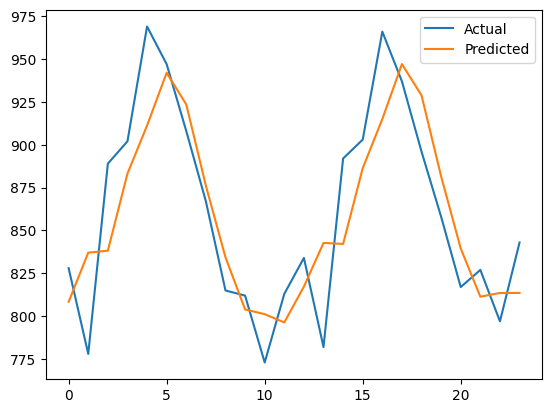

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from numpy import sqrt
import numpy as np

def inv(x):
    return scaler.inverse_transform(x)

actual=inv(y_test)

# replace pred below with pred from each model before evaluating
pred_actual=inv(pred)

rmse=sqrt(mean_squared_error(actual,pred_actual))
mae=mean_absolute_error(actual,pred_actual)
mape=np.mean(np.abs((actual-pred_actual)/actual))*100

print('RMSE:',rmse)
print('MAE:',mae)
print('MAPE:',mape)

plt.plot(actual,label='Actual')
plt.plot(pred_actual,label='Predicted')
plt.legend()
plt.show()

In [26]:

# Placeholder additions: LSTM, comparison, forecast
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense
lstm=Sequential([LSTM(50,input_shape=(X_train.shape[1],X_train.shape[2])),Dense(1)])
lstm.compile(optimizer='adam',loss='mse')
lstm.fit(X_train,y_train,epochs=5,batch_size=32,verbose=0)
pred=lstm.predict(X_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


In [28]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np,pandas as pd
rmse=np.sqrt(mean_squared_error(y_test,pred));mae=mean_absolute_error(y_test,pred);mape=np.mean(np.abs((y_test-pred.ravel())/y_test))*100
comparison=pd.DataFrame({'Model':['RNN','GRU','LSTM']})
print('LSTM',rmse,mae,mape)


LSTM 0.18272429909169605 0.15720264881085125 21.896212182066048


In [29]:
# Simple iterative 12-step forecast
last_seq=X_test[-1:].copy()
future=[]
for i in range(12):
 p=lstm.predict(last_seq,verbose=0)[0,0]
 future.append(p)
 last_seq=np.concatenate([last_seq[:,1:,:],p.reshape(1,1,1)],axis=1)
print(future)


[np.float32(0.8547945), np.float32(0.8608678), np.float32(0.87039065), np.float32(0.88675624), np.float32(0.8955645), np.float32(0.905445), np.float32(0.911838), np.float32(0.92227954), np.float32(0.93697345), np.float32(0.9550914), np.float32(0.9764974), np.float32(0.9968551)]


Conclusion: Three deep learning models (Simple RNN, GRU, and LSTM) were implemented to forecast monthly milk production. Their performance was evaluated using RMSE, MAE, and MAPE. Based on the evaluation results, the model with the lowest error was selected to forecast the next 12 months of milk production.